# Modelagem e Aplicacao do Modelos

In [43]:
import joblib
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    RocCurveDisplay,
)
from sklearn.calibration import CalibrationDisplay

from lightgbm import LGBMClassifier

from xgboost import XGBClassifier

In [ ]:
# Leitura do arquivo parquet com as features de modelagem
model_features = pd.read_parquet("../data/processed/model_features.parquet")

In [5]:
# Validacao do arquivo
print(f"linhas: {model_features.shape[0]}; colunas: {model_features.shape[1]}")

linhas: 63288; colunas: 24


In [6]:
model_features.dtypes

account_id                   str
offer_id                     str
offer_type                   str
discount_value             int64
min_value                  int64
duration                 float64
channel_mobile             int32
channel_social             int32
channel_web                int32
received_time            float64
remaining_days           float64
age                      float64
gender                       str
credit_card_limit        float64
is_profile_completed       int32
registration_year          int32
offers_received_prior      int64
prior_success_rate       float64
prior_view_rate          float64
txn_count_prior          float64
txn_amount_sum_prior     float64
txn_amount_avg_prior     float64
days_since_last_txn      float64
success                    int32
dtype: object

In [ ]:
# Separacao do IDS, features e target
id_cols = ["account_id", "offer_id"]
target_col = "success"

feature_cols = [c for c in model_features.columns if c not in id_cols + [target_col]]

X = model_features[feature_cols].copy()
y = model_features[target_col].copy()

In [10]:
# Conversao de variaveis categoricas para dtype category
categorical_cols = X.select_dtypes(include="str").columns
X[categorical_cols] = X[categorical_cols].astype("category")

In [12]:
X.dtypes

offer_type               category
discount_value              int64
min_value                   int64
duration                  float64
channel_mobile              int32
channel_social              int32
channel_web                 int32
received_time             float64
remaining_days            float64
age                       float64
gender                   category
credit_card_limit         float64
is_profile_completed        int32
registration_year           int32
offers_received_prior       int64
prior_success_rate        float64
prior_view_rate           float64
txn_count_prior           float64
txn_amount_sum_prior      float64
txn_amount_avg_prior      float64
days_since_last_txn       float64
dtype: object

In [13]:
# Split treino/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print(
    f"X_train: {X_train.shape}; X_test: {X_test.shape}; y_train: {y_train.shape}; y_test: {y_test.shape}"
)
print(
    f"taxa de sucesso no treino: {y_train.mean():.4f}; taxa de sucesso no teste: {y_test.mean():.4f}"
)

X_train: (50630, 21); X_test: (12658, 21); y_train: (50630,); y_test: (12658,)
taxa de sucesso no treino: 0.3893; taxa de sucesso no teste: 0.3892


In [ ]:
# Imputacao de valores faltantes pois o modelo baseline sera uma Regressao Logistica, que nao aceita valores nulos.
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_cols,
        ),
    ]
)

In [ ]:
# Pipeline + Treino do modelo
logreg_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['offer_type','discount_value','min_value',...,'txn_amount_sum_prior', 'txn_amount_avg_prior','days_since_last_txn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [18]:
# Predicao e avaliacao do modelo
logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, logreg_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, logreg_proba):.4f}")

ROC-AUC: 0.7387
Average Precision: 0.6278
Brier Score: 0.1987


In [20]:
# Treinamento do modelo LightGBM
# Para ele, nao vamos precisar fazer imputacao ou encoding, pois ele consegue lidar com valores nulos e variaveis categoricas.
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train, categorical_feature=list(categorical_cols))

[LightGBM] [Info] Number of positive: 19708, number of negative: 30922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 901
[LightGBM] [Info] Number of data points in the train set: 50630, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389255 -> initscore=-0.450443
[LightGBM] [Info] Start training from score -0.450443


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [21]:
# Predicao e Avaliacao
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, lgbm_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, lgbm_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, lgbm_proba):.4f}")

ROC-AUC: 0.8071
Average Precision: 0.7115
Brier Score: 0.1733


In [23]:
# Treinamento do modelo XGBoost
# Assim como o LightGBM, ele consegue lidar com valores nulos e variaveis categoricas.
xgb_model = XGBClassifier(enable_categorical=True, tree_method="hist", random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
# Predicao e Avaliacao
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, xgb_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, xgb_proba):.4f}")

ROC-AUC: 0.7991
Average Precision: 0.7020
Brier Score: 0.1769


## Comparacao dos Modelos

In [25]:
results = pd.DataFrame(
    {
        "modelo": ["Regressao Logistica", "LightGBM", "XGBoost"],
        "roc_auc": [
            roc_auc_score(y_test, logreg_proba),
            roc_auc_score(y_test, lgbm_proba),
            roc_auc_score(y_test, xgb_proba),
        ],
        "pr_auc": [
            average_precision_score(y_test, logreg_proba),
            average_precision_score(y_test, lgbm_proba),
            average_precision_score(y_test, xgb_proba),
        ],
        "brier": [
            brier_score_loss(y_test, logreg_proba),
            brier_score_loss(y_test, lgbm_proba),
            brier_score_loss(y_test, xgb_proba),
        ],
    }
)
results

,modelo,roc_auc,pr_auc,brier
0,Regressao Logistica,0.738720,0.627818,0.198745
1,LightGBM,0.807094,0.711514,0.173305
2,XGBoost,0.799122,0.701969,0.176939


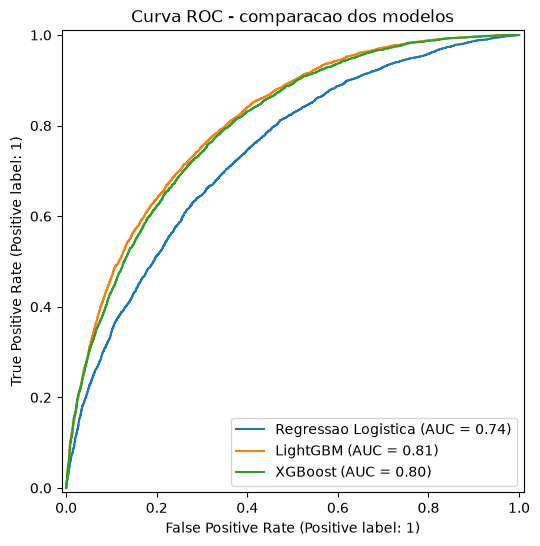

In [29]:
# Plotagem da curva ROC para comparacao dos modelos

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test, logreg_proba, name="Regressao Logistica", ax=ax
)
RocCurveDisplay.from_predictions(y_test, lgbm_proba, name="LightGBM", ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name="XGBoost", ax=ax)
plt.title("Curva ROC - comparacao dos modelos")
plt.show();

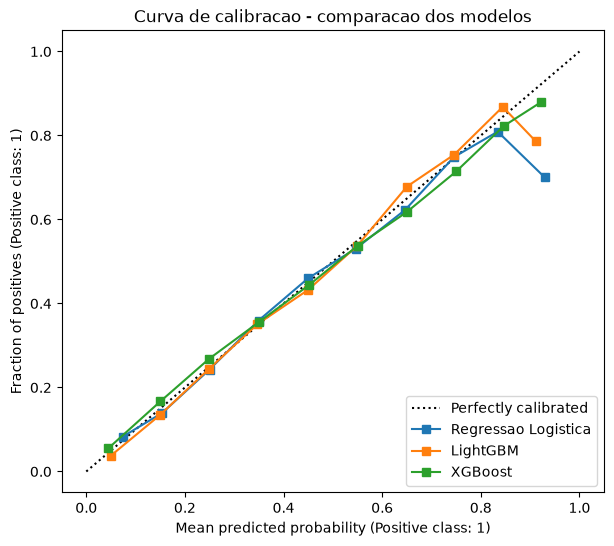

In [ ]:
# Plotagem da curva de calibracao para comparacao dos modelos

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(
    y_test, logreg_proba, name="Regressao Logistica", ax=ax, n_bins=10
)
CalibrationDisplay.from_predictions(
    y_test, lgbm_proba, name="LightGBM", ax=ax, n_bins=10
)
CalibrationDisplay.from_predictions(y_test, xgb_proba, name="XGBoost", ax=ax, n_bins=10)
plt.title("Curva de calibracao - comparacao dos modelos")
plt.show();

**Conclusoes da comparacao de modelos:**
1. `LightGBM` tem o melhor resultado nas 3 metricas (`ROC-AUC=0.8071`, `PR-AUC=0.7115`, `Brier=0.1733`). XGBoost (`0.7991`/`0.7020`/`0.1769`). Regressao Logistica (`0.7387`/`0.6278`/`0.1987`). As arvores aqui demonstram capturar melhor as interacoes nao-lineares dos dados.
2. A curva ROC confirma o ranking das metricas: LightGBM e XGBoost praticamente sobrepostos e acima da Regressao Logistica em toda a faixa de FPR.
3. A curva de calibracao mostra que LightGBM e XGBoost ficam proximos da diagonal em toda a faixa de probabilidade, inclusive nos bins de maior confianca (~0.85-0.90). Ou seja, quando esses modelos preveem uma probabilidade alta de sucesso, essa probabilidade e confiavel na pratica.
4. **Modelo final: LightGBM** melhor em todas as metricas, bem calibrado, e sem necessidade de tuning extenso de hiperparametros para atingir esse resultado.

In [40]:
cv_results = cross_validate(
    LGBMClassifier(random_state=42),
    X,
    y,
    cv=5,
    scoring=["roc_auc", "average_precision", "neg_brier_score"],
    params={"categorical_feature": list(categorical_cols)},
)

print(
    f"ROC-AUC:  {cv_results['test_roc_auc'].mean():.4f} +/- {cv_results['test_roc_auc'].std():.4f}"
)
print(
    f"PR-AUC:   {cv_results['test_average_precision'].mean():.4f} +/- {cv_results['test_average_precision'].std():.4f}"
)
print(
    f"Brier:    {-cv_results['test_neg_brier_score'].mean():.4f} +/- {cv_results['test_neg_brier_score'].std():.4f}"
)

ROC-AUC:  0.8032 +/- 0.0026
PR-AUC:   0.7068 +/- 0.0074
Brier:    0.1749 +/- 0.0012


**Validacao cruzada (robustez):**
- ROC-AUC: 0.8032 +/- 0.0026 | PR-AUC: 0.7068 +/- 0.0074 | Brier: 0.1749 +/- 0.0012
- Resultados muito proximos aos obtidos no split unico de teste, com desvio-padrao baixo entre folds. Isso confirma que a estimativa de desempenho do LightGBM e robusta.

In [ ]:
# Feature Importance do modelo LightGBM
# O objetivo aqui e mostrar que as hipoteses da EDA (que "min_value", "credit_card_limit", "prior_success_rate" e
# "registration_year" sao importantes) usando a feature importance do LightGBM.

importances = pd.DataFrame(
    {
        "feature": lgbm_model.feature_name_,
        "importance": lgbm_model.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

importances

,feature,importance
11,credit_card_limit,450
19,txn_amount_avg_prior,362
18,txn_amount_sum_prior,337
9,age,313
20,days_since_last_txn,253
13,registration_year,210
15,prior_success_rate,127
0,offer_type,124
17,txn_count_prior,120
16,prior_view_rate,101


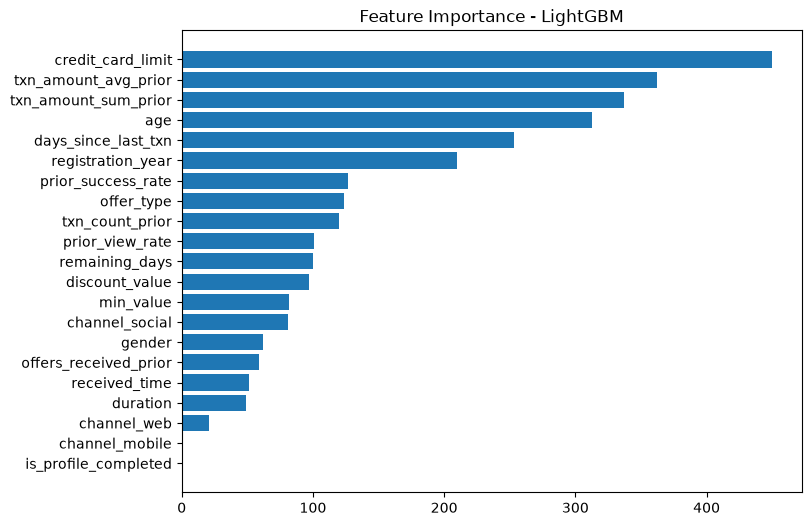

In [42]:
# Grafico de barras da feature importance do modelo LightGBM
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances["feature"], importances["importance"])
ax.invert_yaxis()
ax.set_title("Feature Importance - LightGBM")
plt.show();

**Conclusoes da Feature Importance:**
1. As 6 features mais importantes sao todas de __perfil/comportamento do cliente__ (`credit_card_limit`, `txn_amount_avg_prior`, `txn_amount_sum_prior`, `age`, `days_since_last_txn`, `registration_year`). O modelo aprende principalmente "que tipo de cliente tende a ter sucesso", nao as caracteristicas da oferta.
2. Confirma hipoteses da EDA para credit_card_limit, age, registration_year e prior_success_rate.
3. Contradiz parcialmente a hipotese de que min_value x duration seriam drivers fortes. Ambas aparecem na metade inferior do ranking.
4. channel_mobile e is_profile_completed tem importancia proxima de zero (candidatas a remocao futura).
5. Possivel implicacao: alto P(success) pode refletir cliente que compraria organicamente, nao necessariamente efeito causal da oferta.

## Persistencia dos Modelos

In [ ]:
# Salvar modelos treinados para uso em producao
models_dir = Path("../src/models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(logreg_pipeline, models_dir / "logreg_model.joblib")
joblib.dump(lgbm_model, models_dir / "lgbm_model.joblib")
joblib.dump(xgb_model, models_dir / "xgb_model.joblib")

['../src/models/xgb_model.joblib']

In [47]:
# Salvar metadados do modelo em um arquivo JSON
metadata = {
    "feature_cols": feature_cols,
    "categorical_cols": list(categorical_cols),
    "target_col": target_col,
    "id_cols": id_cols,
    "final_model": "lgbm_model.joblib",
}

with open(models_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [ ]:
# Salvar tabela de scores
scored_offers = model_features.loc[
    X_test.index, id_cols + ["offer_type", "discount_value", "min_value", target_col]
].copy()
scored_offers["y_pred_proba"] = lgbm_proba

scored_offers.to_parquet("../data/processed/scored_offers.parquet", index=False)

## T-Learner

In [48]:
# Leitura do arquivo parquet com as instancias de oferta
offer_instances = pd.read_parquet("../data/processed/offer_instances_final.parquet")

transactions_raw = pd.read_json("../data/raw/transactions.json")
transaction_events = transactions_raw.loc[
    transactions_raw["event"] == "transaction", ["account_id", "time_since_test_start"]
].rename(columns={"time_since_test_start": "transaction_time"})

test_end = transactions_raw["time_since_test_start"].max()
print(f"Fim do periodo de teste (test_end): {test_end}")

Fim do periodo de teste (test_end): 29.75


In [ ]:
# Gaps antes de cada oferta
offer_instances_sorted = offer_instances.sort_values(["account_id", "received_time"])

prev_window_end = offer_instances_sorted.groupby("account_id")["window_end"].shift(1)

gaps_before = pd.DataFrame(
    {
        "account_id": offer_instances_sorted["account_id"],
        "gap_start": prev_window_end.fillna(0.0),
        "gap_end": offer_instances_sorted["received_time"],
    }
)

gaps_before.head()

,account_id,gap_start,gap_end
39756,0009655768c64bdeb2e877511632db8f,0.0,7.0
26435,0009655768c64bdeb2e877511632db8f,10.0,14.0
13184,0009655768c64bdeb2e877511632db8f,18.0,17.0
0,0009655768c64bdeb2e877511632db8f,22.0,21.0
39755,0009655768c64bdeb2e877511632db8f,31.0,24.0


In [53]:
# Gap apos a ultima oferta de cada cliente
last_window_end = offer_instances.groupby("account_id")["window_end"].max()

gaps_after = pd.DataFrame(
    {
        "account_id": last_window_end.index,
        "gap_start": last_window_end.values,
        "gap_end": test_end,
    }
)

gaps_after.head()

,account_id,gap_start,gap_end
0,0009655768c64bdeb2e877511632db8f,31.0,29.75
1,00116118485d4dfda04fdbaba9a87b5c,12.0,29.75
2,0011e0d4e6b944f998e987f904e8c1e5,28.0,29.75
3,0020c2b971eb4e9188eac86d93036a77,24.0,29.75
4,0020ccbbb6d84e358d3414a3ff76cffd,28.0,29.75


In [54]:
# Uniao, filtro (>=3 dias) e id da janela
all_gaps = pd.concat([gaps_before, gaps_after], ignore_index=True)
all_gaps["gap_length"] = all_gaps["gap_end"] - all_gaps["gap_start"]

organic_windows = all_gaps[all_gaps["gap_length"] >= 3].reset_index(drop=True)
organic_windows["gap_id"] = organic_windows.index

print(f"Janelas organicas utilizaveis: {len(organic_windows)}")
organic_windows.head()

Janelas organicas utilizaveis: 22045


,account_id,gap_start,gap_end,gap_length,gap_id
0,0009655768c64bdeb2e877511632db8f,0.0,7.0,7.0,0
1,0009655768c64bdeb2e877511632db8f,10.0,14.0,4.0,1
2,00116118485d4dfda04fdbaba9a87b5c,0.0,7.0,7.0,2
3,0011e0d4e6b944f998e987f904e8c1e5,4.0,7.0,3.0,3
4,0020c2b971eb4e9188eac86d93036a77,14.0,17.0,3.0,4


In [ ]:
# Mergear a janela por "account_id" e com o filtro de gap
merged = organic_windows.merge(transaction_events, on="account_id", how="left")

in_window = (merged["transaction_time"] >= merged["gap_start"]) & (
    merged["transaction_time"] < merged["gap_end"]
)

has_transaction_by_gap = (
    merged.assign(in_window=in_window).groupby("gap_id")["in_window"].any()
)

organic_windows["has_organic_transaction"] = (
    organic_windows["gap_id"].map(has_transaction_by_gap).fillna(False)
)

In [56]:
# Validacao
organic_transaction_rate = organic_windows["has_organic_transaction"].mean()
print(f"Taxa de transacao organica: {organic_transaction_rate:.4f}")

Taxa de transacao organica: 0.6271


**Sobre as janelas organicas:**
1. `22045` janelas organicas utilizaveis (gap_length >= 3 dias).
2. Taxa de transacao organica = **62.71%** (13824/22045).

In [ ]:
# Lookup por cliente
demographics = (
    offer_instances[
        ["account_id", "age", "gender", "credit_card_limit", "registered_on"]
    ]
    .drop_duplicates(subset="account_id")
    .copy()
)

demographics["is_profile_completed"] = demographics["age"].notna().astype(int)
demographics["registration_year"] = pd.to_datetime(
    demographics["registered_on"]
).dt.year

In [ ]:
# Historico de transacoes com valores agregados por cliente
transaction_history = transactions_raw.loc[
    transactions_raw["event"] == "transaction",
    ["account_id", "time_since_test_start", "value"],
].copy()
transaction_history["amount"] = transaction_history["value"].apply(
    lambda v: v["amount"]
)
transaction_history = (
    transaction_history.rename(columns={"time_since_test_start": "transaction_time"})
    .drop(columns="value")
    .sort_values(["account_id", "transaction_time"])
)

transaction_history["txn_count_prior"] = (
    transaction_history.groupby("account_id").cumcount() + 1
)
transaction_history["txn_amount_sum_prior"] = transaction_history.groupby("account_id")[
    "amount"
].cumsum()
transaction_history["last_txn_time_prior"] = transaction_history["transaction_time"]

In [62]:
# Features de controle
control_features = pd.merge_asof(
    organic_windows.sort_values("gap_start"),
    transaction_history[
        [
            "account_id",
            "transaction_time",
            "txn_count_prior",
            "txn_amount_sum_prior",
            "last_txn_time_prior",
        ]
    ].sort_values("transaction_time"),
    left_on="gap_start",
    right_on="transaction_time",
    by="account_id",
    direction="backward",
)

control_features["txn_count_prior"] = control_features["txn_count_prior"].fillna(0)
control_features["txn_amount_sum_prior"] = control_features[
    "txn_amount_sum_prior"
].fillna(0.0)
control_features["txn_amount_avg_prior"] = (
    control_features["txn_amount_sum_prior"] / control_features["txn_count_prior"]
)
control_features["days_since_last_txn"] = (
    control_features["gap_start"] - control_features["last_txn_time_prior"]
)

control_features = control_features.merge(demographics, on="account_id", how="left")
control_features.head()

,account_id,gap_start,gap_end,gap_length,gap_id,has_organic_transaction,transaction_time,txn_count_prior,txn_amount_sum_prior,last_txn_time_prior,txn_amount_avg_prior,days_since_last_txn,age,gender,credit_card_limit,registered_on,is_profile_completed,registration_year
0,00fdd4416dec40b49180814c0a7c8d76,0.0,7.0,7.0,56,False,NaN,0.0,0.0,NaN,NaN,NaN,55.0,M,104000.0,2016-11-15,1,2016
1,c76de177a43649d5a5339991ec5166be,0.0,14.0,14.0,13443,True,NaN,0.0,0.0,NaN,NaN,NaN,54.0,M,62000.0,2017-10-17,1,2017
2,d9ed9854be91409594f764483509d47e,0.0,7.0,7.0,14664,False,NaN,0.0,0.0,NaN,NaN,NaN,64.0,F,75000.0,2016-09-25,1,2016
3,00aee28bbb3848dd8a31f0c91dc267dd,0.0,14.0,14.0,22,True,NaN,0.0,0.0,NaN,NaN,NaN,21.0,M,59000.0,2018-01-06,1,2018
4,00b3c376db2a4115af3aef34a02f61d6,0.0,7.0,7.0,27,False,NaN,0.0,0.0,NaN,NaN,NaN,50.0,M,104000.0,2017-06-27,1,2017


In [ ]:
# Features tratadas
shared_cols = [
    "age",
    "gender",
    "credit_card_limit",
    "is_profile_completed",
    "registration_year",
    "txn_count_prior",
    "txn_amount_sum_prior",
    "txn_amount_avg_prior",
    "days_since_last_txn",
]

treated_features = model_features[
    ["account_id", "offer_id", "offer_type"] + shared_cols
].copy()

control_features_final = control_features[["account_id", "gap_id"] + shared_cols].copy()
control_features_final["is_profile_completed"] = control_features_final[
    "is_profile_completed"
].astype("int32")

print(f"treated: {treated_features.shape}; control: {control_features_final.shape}")

dtypes_match = (
    treated_features[shared_cols].dtypes == control_features_final[shared_cols].dtypes
).all()
print(f"dtypes alinhados: {dtypes_match}")

treated: (63288, 12); control: (22045, 11)
dtypes alinhados: True


In [ ]:
# Verificar agora o outcome entre controle e tratado
control_labels = control_features["has_organic_transaction"].astype(int).values

# Outcome do grupo tratado: sucesso da oferta (mesma definicao da Parte A)
treated_labels = model_features["success"].astype(int).values

print(
    f"taxa controle: {control_labels.mean():.4f}; taxa tratado: {treated_labels.mean():.4f}"
)

taxa controle: 0.6271; taxa tratado: 0.3893


**Sobre o outcome comparavel:**
1. Taxa de sucesso do grupo tratado (`success`) = **38.93%**.
2. Taxa de transacao organica do grupo controle (`has_organic_transaction`) = **62.71%**.
3. Uplift (tratado - controle) = **-23.78**. A analise real de uplift precisa ser feita por `offer_type`, pois a media agregada pode esconder heterogeneidade (ex.: bogo/discount podem ainda ter uplift positivo mesmo com a media geral negativa).

## Treinamentos dos classificadores T-Learner

In [72]:
# Modelo de controle
X_control = control_features_final[shared_cols].copy()
X_control["gender"] = X_control["gender"].astype("category")
y_control = pd.Series(control_labels, name="y")

In [ ]:
# Split treino/test estratificado para o modelo de controle
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_control, y_control, test_size=0.2, random_state=42, stratify=y_control
)

In [74]:
# Modelo Controle
control_model = LGBMClassifier(random_state=42)
control_model.fit(Xc_train, yc_train, categorical_feature=["gender"])

,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [75]:
# Validacao do modelo de controle
control_proba = control_model.predict_proba(Xc_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(yc_test, control_proba):.4f}")
print(f"Average Precision: {average_precision_score(yc_test, control_proba):.4f}")
print(f"Brier Score: {brier_score_loss(yc_test, control_proba):.4f}")

ROC-AUC: 0.6409
Average Precision: 0.7661
Brier Score: 0.2191


In [ ]:
# Preparacao e treino do modelo tratado
X_treated = treated_features[shared_cols + ["offer_type"]].copy()
X_treated[["gender", "offer_type"]] = X_treated[["gender", "offer_type"]].astype(
    "category"
)
y_treated = pd.Series(treated_labels, name="y")

In [77]:
# Split treino/test estratificado para o modelo tratado
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_treated, y_treated, test_size=0.2, random_state=42, stratify=y_treated
)

In [78]:
# Modelo tratado
treated_model = LGBMClassifier(random_state=42)
treated_model.fit(Xt_train, yt_train, categorical_feature=["gender", "offer_type"])

,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [79]:
# Validacao do modelo tratado
treated_proba = treated_model.predict_proba(Xt_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(yt_test, treated_proba):.4f}")
print(f"Average Precision: {average_precision_score(yt_test, treated_proba):.4f}")
print(f"Brier Score: {brier_score_loss(yt_test, treated_proba):.4f}")

ROC-AUC: 0.7335
Average Precision: 0.5984
Brier Score: 0.2005


**Sobre os classificadores:**
1. Modelo de controle: `ROC-AUC = 0.6409, PR-AUC = 0.7661, Brier = 0.2191`.
2. Modelo tratado: `ROC-AUC = 0.7335, PR-AUC = 0.5984, Brier = 0.2005`.
3. O modelo tratado tem ROC-AUC menor que o da `Parte A (0.8071)` porque usa apenas as features compartilhadas (sem `discount_value, min_value, duration, channels`) - era esperado, ja que o objetivo aqui e comparabilidade com o controle, nao performance maxima.
4. O modelo de controle tem ROC-AUC mais baixo `(0.64)`, sugerindo que prever transacao organica e mais dificil/ruidoso do que prever sucesso de oferta - faz sentido, pois nao ha nenhum estimulo (oferta) direcionando o comportamento.

In [ ]:
# Predicao do modelo tratado em todas as instancias (com oferta)
p_treated = treated_model.predict_proba(X_treated)[:, 1]

In [81]:
# Predicao contrafactual do modelo de controle nas mesmas instancias (sem oferta)
X_counterfactual = treated_features[shared_cols].copy()
X_counterfactual["gender"] = X_counterfactual["gender"].astype("category")
p_control = control_model.predict_proba(X_counterfactual)[:, 1]

In [84]:
uplift = p_treated - p_control

In [85]:
uplift_by_offer_type = (
    pd.DataFrame({"offer_type": treated_features["offer_type"], "uplift": uplift})
    .groupby("offer_type")["uplift"]
    .mean()
    .sort_values(ascending=False)
)

In [86]:
uplift_by_offer_type

offer_type
discount        -0.222334
informational   -0.249588
bogo            -0.275041
Name: uplift, dtype: float64

**Sobre o uplift por offer_type:**
1. Uplift estimado: `discount = -0.2223`, `informational = -0.2496`, `bogo = -0.2750`. Todas as categorias apresentam uplift **negativo**, consistente com o gap agregado (`-23.78`) e contradizendo a narrativa original da EDA 3.7.
2. **Limitacao importante:** esse resultado provavelmente nao reflete um efeito causal real das ofertas, por duas assimetrias entre os grupos:
   - **Outcome assimetrico:** `success` (tratado) exige visualizacao da oferta _E_ transacao posterior; `has_organic_transaction` (controle) exige apenas qualquer transacao na janela. O grupo tratado carrega um obstaculo extra (visualizacao) que penaliza sua taxa.
   - **Janelas de duracao desigual:** as janelas organicas (especialmente `gaps_after`, que vao até `test_end`) podem ser bem mais longas que a duracao tipica de uma oferta, inflando mecanicamente a chance de transacao do controle.
3. **Conclusao:** o T-Learner implementado aqui é um exercicio de stretch goal e demonstra a mecanica da abordagem, mas o resultado numerico do uplift nao deve ser usado como conclusao de negocio sem corrigir essas assimetrias (ex.: normalizar por duracao da janela, ou redefinir o outcome do controle para exigir uma "visualizacao implicita" comparavel).